# PCA+SVM vs. LDA: Fisher Iris Classification  
Load data then split into training and testing with stratify.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# scikit-learn
from sklearn import datasets # for loading of datasets included in scikit-learn
from sklearn.svm import SVC # for implementation of SVC
from sklearn.decomposition import PCA # for implementation of PCA
from sklearn.metrics import confusion_matrix # for evaluation
from sklearn.model_selection import train_test_split # for data splitting
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # for implementation of LDA

# Reference: https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html

In [2]:
# loading iris dataset
iris = datasets.load_iris()

# isolating features and classes
X = iris.data 
y = iris.target
target_names = iris.target_names

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)

Perform PCA and LDA, then compare the 2D results.

PCA:

First 10 X_train_pca: 
[[ 0.93243049 -0.58026043]
 [-2.65963192  0.26306233]
 [-0.91504738 -0.78453978]
 [-2.37160853 -0.05255648]
 [ 1.95689203 -0.15370643]
 [-3.23290232  0.10511974]
 [-2.70398665  0.27895506]
 [ 1.88823246  0.07632653]
 [ 2.54422732  0.30638776]
 [ 1.3774312  -0.25213402]]

First 10 X_test_pca: 
[[-2.60908675  0.18765459]
 [ 3.77467532  0.25541239]
 [ 1.19908875  0.3946767 ]
 [-2.64438428  0.12623472]
 [ 0.34563475 -0.50546129]
 [-2.41567712  1.31450816]
 [ 0.17488062 -0.84815587]
 [-2.58284642  0.32638708]
 [ 1.78887408 -0.21234407]
 [ 0.49655219 -0.10405561]]


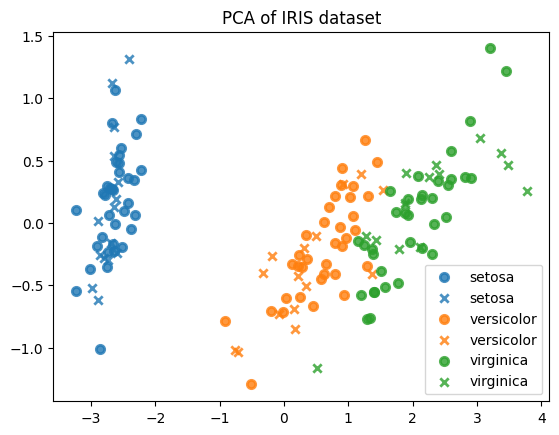

In [3]:
# performing PCA
pca = PCA(n_components=2) # initializing PCA object with 2 principal components for dimensionality reduction
X_train_pca = pca.fit_transform(X_train, y_train) # fit the model with X and apply the dimensionality reduction on X
X_test_pca = pca.transform(X_test) # apply dimensionality reduction to X; X is projected on the first principal components previously extracted from a training set

# showing PCA-transformed X, for documentation
print(f"First 10 X_train_pca: \n{X_train_pca[:10]}\n")
print(f"First 10 X_test_pca: \n{X_test_pca[:10]}")

# showing PCA results
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # blue, orange, green
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    # plotting training data, PCA-transformed
    plt.scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1], 
                color=color, alpha=0.8, lw=2, label=target_name)
    # plotting test data, PCA-transformed
    plt.scatter(X_test_pca[y_test == i, 0], X_test_pca[y_test == i, 1], 
                color=color, alpha=0.8, lw=2, label=target_name, marker='x')
    
plt.legend(loc="best", shadow=False)
plt.title("PCA of IRIS dataset")
plt.show()

LDA:

First 10 X_train_lda: 
[[-4.14913582  1.6434829 ]
 [ 9.09263045  0.03893664]
 [ 0.70894489  0.53420317]
 [ 7.46631944  0.48485975]
 [-6.41708113  0.40121941]
 [10.14442402 -0.92804879]
 [ 9.21898798 -0.18716478]
 [-5.68572407 -0.09187681]
 [-7.53177323 -1.46350164]
 [-5.15243926 -0.42445911]]

First 10 X_test_lda: 
[[  8.75342463   0.12373115]
 [-10.77564135   1.02640938]
 [ -2.57484021   0.12936822]
 [  8.68370653   0.10178058]
 [ -2.28138461   0.84369261]
 [ 10.6352709   -2.4589766 ]
 [ -2.59642974   1.4248553 ]
 [  9.01921835  -0.05846914]
 [ -6.17966035   0.17478514]
 [ -1.98122197  -0.37581087]]


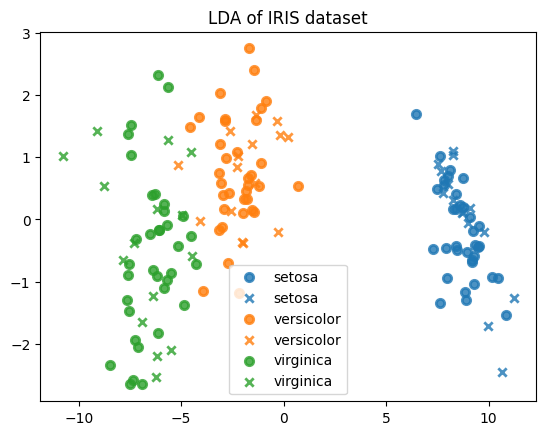

In [4]:
# performing LDA
lda = LinearDiscriminantAnalysis(n_components=2) # initializing LDA object with 2 components for dimensionality reduction
X_train_lda = lda.fit_transform(X_train, y_train) # fit to data, then transform it
X_test_lda = lda.transform(X_test) # project data to maximize class separation.

# showing LDA-transformed X, for documentation
print(f"First 10 X_train_lda: \n{X_train_lda[:10]}\n")
print(f"First 10 X_test_lda: \n{X_test_lda[:10]}")

# showing LDA results
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    # plotting training data, LDA-transformed
    plt.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], 
                color=color, alpha=0.8, lw=2, label=target_name)
    # plotting test data, LDA-transformed
    plt.scatter(X_test_lda[y_test == i, 0], X_test_lda[y_test == i, 1], 
                color=color, alpha=0.8, lw=2, label=target_name, marker='x')
    
plt.legend(loc="best", shadow=False)
plt.title("LDA of IRIS dataset")
plt.show()

## LDA Classification Results
Check the accuracy of LDA on training and testing data.

In [5]:
# evaluating LDA
print(f"Training Accuracy: {lda.score(X_train,y_train)}")
print()
print('Training: Confusion Matrix')
print(confusion_matrix(y_train, lda.predict(X_train)))

print()
print("=====")
print()

print(f"Testing Accuracy: {lda.score(X_test,y_test)}")
print()
print('Testing: Confusion Matrix')
print(confusion_matrix(y_test, lda.predict(X_test)))

Training Accuracy: 0.9904761904761905

Training: Confusion Matrix
[[35  0  0]
 [ 0 34  1]
 [ 0  0 35]]

=====

Testing Accuracy: 0.9555555555555556

Testing: Confusion Matrix
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]


## PCA+SVM Classification Results
Perform SVM on PCA scores, then report accuracies.

In [6]:
# performing SVM on the PCA-transformed data
svm_mdl = SVC().fit(X_train,y_train)
print(f"Training Accuracy: {svm_mdl.score(X_train,y_train)}")
print()
print('Training: Confusion Matrix')
print(confusion_matrix(y_train, svm_mdl.predict(X_train)))

print()
print("=====")
print()

print(f"Testing Accuracy: {svm_mdl.score(X_test,y_test)}")
print()
print('Testing: Confusion Matrix')
print(confusion_matrix(y_test, svm_mdl.predict(X_test)))

Training Accuracy: 0.9809523809523809

Training: Confusion Matrix
[[35  0  0]
 [ 0 35  0]
 [ 0  2 33]]

=====

Testing Accuracy: 0.9333333333333333

Testing: Confusion Matrix
[[15  0  0]
 [ 0 13  2]
 [ 0  1 14]]
